In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, f1_score


In [6]:
url = r"C:\Users\Neil\Downloads\emplyee attrition.csv"
df = pd.read_csv(url)
df.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59598 entries, 0 to 59597
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee ID               59598 non-null  int64 
 1   Age                       59598 non-null  int64 
 2   Gender                    59598 non-null  object
 3   Years at Company          59598 non-null  int64 
 4   Job Role                  59598 non-null  object
 5   Monthly Income            59598 non-null  int64 
 6   Work-Life Balance         59598 non-null  object
 7   Job Satisfaction          59598 non-null  object
 8   Performance Rating        59598 non-null  object
 9   Number of Promotions      59598 non-null  int64 
 10  Overtime                  59598 non-null  object
 11  Distance from Home        59598 non-null  int64 
 12  Education Level           59598 non-null  object
 13  Marital Status            59598 non-null  object
 14  Number of Dependents  

In [8]:
if "Employee ID" in df.columns:
    df.drop(columns=["Employee ID"], inplace=True)

In [9]:
#Encode categorical variables
label_encoders = {}
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col]=le.fit_transform(df[col])
    label_encoders[col] = le

In [10]:
df

,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,31,1,19,0,5390,0,2,0,2,0,...,0,1,1,89,0,0,0,0,2,1
1,59,0,4,3,5534,3,0,3,3,0,...,3,1,1,21,0,0,0,1,1,1
2,24,0,10,2,8159,2,0,3,0,0,...,3,1,1,74,0,0,0,3,1,1
3,36,0,7,0,3989,2,0,2,1,0,...,2,1,2,50,1,0,0,2,2,1
4,56,1,41,0,4821,1,3,0,0,1,...,0,2,1,68,0,0,0,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59593,50,0,12,0,4414,1,0,0,1,1,...,2,2,2,35,0,0,1,3,3,0
59594,18,1,4,2,8040,1,0,2,3,0,...,0,2,1,73,0,0,0,1,2,0
59595,22,0,14,4,7944,1,0,2,0,1,...,2,0,2,29,0,1,0,2,2,1
59596,23,1,8,0,2931,1,3,0,0,0,...,0,0,0,9,0,0,0,2,1,0


In [11]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Attrition
1    31260
0    28338
Name: count, dtype: int64


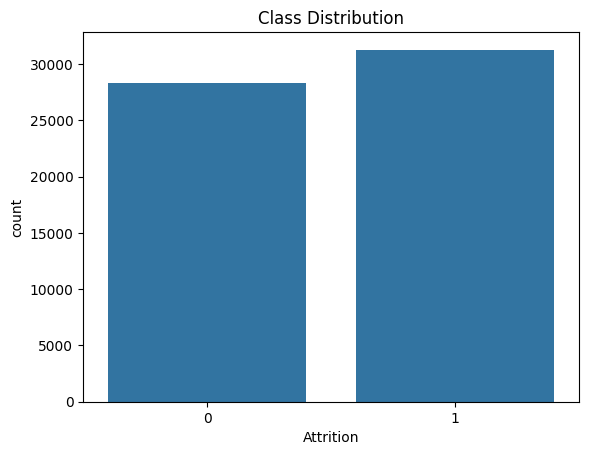

In [13]:
# Check class distribution
print(y.value_counts())

# Visualize class distribution
sns.countplot(x='Attrition', data=df)
plt.title('Class Distribution')
plt.show()


In [14]:
from imblearn.over_sampling import SMOTE

# If you're using SMOTE (Synthetic Minority Oversampling Technique) to balance the dataset:
smote = SMOTE()
X_res, y_res = smote.fit_resample(X_train, y_train)

# After applying SMOTE, check the new distribution of the classes:
print(pd.Series(y_res).value_counts())


Attrition
1    25007
0    25007
Name: count, dtype: int64


In [15]:
# My Notes :-
# hyperparameters :- MaxDepth, n_estimators, max_leaf_nodes, max_no_features, 
# n_estimators - Number of Trees -> More the trees more the overfitting
param_grid = { 'n_estimators' : [50,100,200],
                'max_depth' : [5,10,20],
                'min_samples_split' : [2,5,10],
                'min_samples_leaf' : [1,2,4]
             }



In [16]:
rf_classifier = RandomForestClassifier(random_state=42)

# using Grid Search 
grid_search = GridSearchCV(estimator=rf_classifier, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)


In [17]:
# Fit GridSearchCV to training data
grid_search.fit(X_train, y_train)

# Get the best parameters found by GridSearchCV
best_params = grid_search.best_params_
print(f"Best Parameters: {best_params}")


Fitting 3 folds for each of 81 candidates, totalling 243 fits
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


In [18]:
# Get the best model
best_rf_model = RandomForestClassifier(**best_params, random_state=42)
best_rf_model.fit(X_train,y_train)

# Predict on the test set
y_pred = best_rf_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy on Test Set: {accuracy:.2f}")

# You can also get more detailed metrics
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Accuracy on Test Set: 0.74
              precision    recall  f1-score   support

           0       0.73      0.73      0.73      5667
           1       0.75      0.76      0.76      6253

    accuracy                           0.74     11920
   macro avg       0.74      0.74      0.74     11920
weighted avg       0.74      0.74      0.74     11920

[[4110 1557]
 [1514 4739]]


In [19]:
# Feature importance visualization
feature_importances = pd.Series(best_rf_model.feature_importances_,index=df.drop(columns=['fraud_reported']).columns)
feature_importances.sort_values(ascending=False).plot(kind='bar',figsize=(10,5),title="feature importance in random forest")
plt.show()

KeyError: "['fraud_reported'] not found in axis"